In [1]:
# some standard python imports #
import numpy as np
import copy
import matplotlib.pyplot as plt

import lenstronomy
from lenstronomy.Data.pixel_grid import PixelGrid
from lenstronomy.Data.psf import PSF
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.ImSim.image_model import ImageModel
import lenstronomy.Util.param_util as param_util


In [2]:
# define the numerics 
kwargs_numerics = {'supersampling_factor': 1, 'supersampling_convolution': False}
deltaPix = 0.055 #0.05  

# setup the keyword arguments to create the Data() class #
ra_at_xy_0, dec_at_xy_0 = -2.5, -2.5 # coordinate in angles (RA/DEC) at the position of the pixel edge (0,0)
transform_pix2angle = np.array([[1, 0], [0, 1]]) * deltaPix  # linear translation matrix of a shift in pixel in a shift in coordinates
kwargs_pixel = {'nx': 100, 'ny': 100, 'ra_at_xy_0': ra_at_xy_0, 'dec_at_xy_0': dec_at_xy_0, 
                'transform_pix2angle': transform_pix2angle} 
pixel_grid = PixelGrid(**kwargs_pixel)

#PSF
kwargs_psf = {'psf_type': 'GAUSSIAN', 'fwhm': 0.1 , 'pixel_size': deltaPix} #0.1
psf = PSF(**kwargs_psf)
#kernel = psf.kernel_point_source # return the pixel kernel corresponding to a point source # 

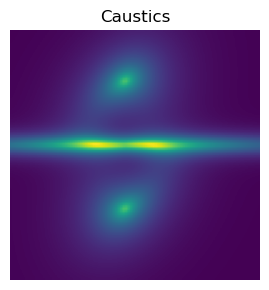

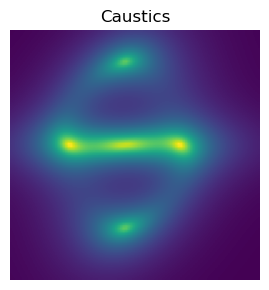

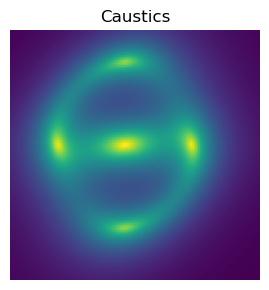

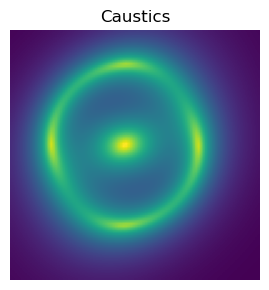

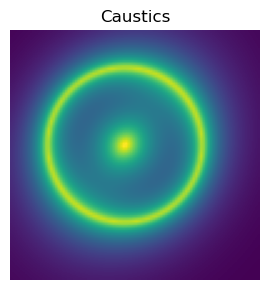

In [3]:
# Mass Model
lensModel = LensModel(lens_model_list=['SIE'])
lightModel_source = LightModel(light_model_list=['SERSIC_ELLIPSE'])
lightModel_lens = LightModel(light_model_list=['SERSIC_ELLIPSE'])

# initialize the Image model class by combining the modules we created above #
imageModel = ImageModel(data_class=pixel_grid, psf_class=psf, lens_model_class=lensModel,
                        source_model_class=lightModel_source, lens_light_model_class=lightModel_lens,
                        point_source_class=None, kwargs_numerics=kwargs_numerics)


x = np.linspace(0.05, 1, 5, dtype=np.float32)
for i in range(len(x)):
    # Mass model
    e1, e2 = param_util.phi_q2_ellipticity(phi=0., q=x[i])
    kwargs_sie = {'theta_E': 1.7, 'e1': e1, 'e2': e2, 'center_x': 0.0, 'center_y': 0}
    kwargs_lens = [kwargs_sie]

    # light source
    e1, e2 = param_util.phi_q2_ellipticity(phi=-0.985, q=0.7) 
    kwargs_light_source = [{'amp': 5, 'R_sersic': 1., 'n_sersic': 1.3, 'e1': e1, 'e2': e2,
                            'center_x': 0, 'center_y': 0}]
    #kwargs_light_source = [{'amp': 2, 'R_sersic': 0.1, 'n_sersic': 1.5, 'e1': e1, 'e2': e2,
    #                        'center_x': 0, 'center_y': 0}] #100
    # light lens
    e1, e2 = param_util.phi_q2_ellipticity(phi=0., q=x[i])
    kwargs_light_lens = [{'amp': 10, 'R_sersic': 1, 'n_sersic': 1., 'e1': e1, 'e2': e2, 
                          'center_x': 0, 'center_y': 0}]
    #kwargs_light_lens = [{'amp': 5, 'R_sersic': 0.1, 'n_sersic': 2.5, 'e1': e1, 'e2': e2, 
    #                      'center_x': 0.1, 'center_y': 0}] #1000

    image = imageModel.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_light_source,
                         kwargs_lens_light=kwargs_light_lens)

    plt.figure(figsize = (3,3))
    #plt.imshow(np.log10(image))
    plt.title('Caustics', fontsize=12)
    plt.imshow(image)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('for_gif/lens_' + str(i) + '.png')
    plt.show()
    plt.close()

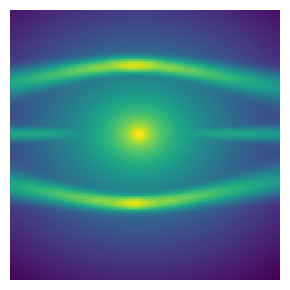

In [4]:



# define parameter values of lens models #
e1, e2 = param_util.phi_q2_ellipticity(phi=0., q=0.05)
kwargs_sie = {'theta_E': 1.7, 'e1': e1, 'e2': e2, 'center_x': 0.0, 'center_y': 0}
kwargs_lens = [kwargs_sie]

# define the parameters #
kwargs_light_source = [{'amp': 2, 'R_sersic': 0.1, 'n_sersic': 1.5, 'e1': e1, 'e2': e2,
                            'center_x': 0, 'center_y': 0}]
e1, e2 = param_util.phi_q2_ellipticity(phi=0., q=0.8)
kwargs_light_lens = [{'amp': 5, 'R_sersic': 0.1, 'n_sersic': 2.5, 'e1': e1, 'e2': e2, 
                          'center_x': 0.1, 'center_y': 0}]

image = imageModel.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_light_source,
                         kwargs_lens_light=kwargs_light_lens)


plt.figure(figsize = (3,3))
plt.imshow(np.log10(image))
plt.axis('off')
plt.tight_layout()
plt.show()
plt.close()

In [5]:
import matplotlib.image as mpimg

for i in range(len(x)):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    
    axes[0].imshow(mpimg.imread(f'for_gif/caus_{i}.png'))
    axes[0].set_title('Caustics')
    axes[0].axis('off')
    
    axes[1].imshow(mpimg.imread(f'for_gif/lens_{i}.png'))
    axes[1].set_title('Lenstronomy')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'for_gif/sim_{i}.png')
    plt.close()

In [6]:
import imageio

images = [imageio.imread(f'for_gif/sim_{i}.png') for i in range(len(x))]
imageio.mimsave('for_gif/simulation.gif', images, fps=1)

/Users/jimenagonzalez/Software/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning dissapear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  This is separate from the ipykernel package so we can avoid doing imports until
